## Project Overview

This project analyzes retail sales data to identify key drivers of revenue and profitability. The goal is to transform raw transactional data into actionable business insights through data cleaning, aggregation, and visualization.

## Business Problem

Retail businesses need to understand which regions, product categories, and discount strategies drive sales and profit.

This analysis answers:

- Which region generates the most revenue?
- Which categories perform best?
- How do sales change over time?
- Does discounting impact profitability?

Success is defined as producing clear insights that can guide business decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Overview

The dataset contains transactional sales records with the following key fields:

- Order Date: Date of transaction
- Region: Geographic sales region
- Category: Product category
- Sales: Revenue generated
- Profit: Profit earned
- Discount: Discount applied

Each row represents a single sales transaction.
    

In [7]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\sales-dashboard-project\\data\\SuperStoreOrders.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [8]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

## Data Cleaning

The dataset was cleaned to ensure accuracy and consistency:

- Removed duplicate records to avoid double counting
- Converted date columns to datetime format for time-based analysis
- Checked for missing values (none significant found)
- Created Month and Year features for trend analysis

In [9]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [10]:
df = df.drop_duplicates()

## Feature Engineering

To support time-based analysis:

- Extracted Month from Order Date
- Extracted Year for yearly comparisons

In [17]:
# Inspect raw values
print(df["order_date"].sample(20))

# Convert safely
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], format="mixed", dayfirst=True)

# Validate
print(df["order_date"].isna().sum())

10666      3/4/2012
17374     5/11/2012
20932    13-02-2013
6347     20-10-2011
15668    17-09-2012
19613    24-12-2012
256      20-01-2011
23315    15-05-2013
44920    24-09-2014
38611    27-05-2014
12924    21-06-2012
49471     4/12/2014
21101    21-02-2013
24569    13-06-2013
23406    17-05-2013
37109    17-04-2014
8296     15-12-2011
49097    29-11-2014
21445      7/3/2013
18568    28-11-2012
Name: order_date, dtype: object
0


In [18]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                     object
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

In [28]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
avg_order_value = total_sales / total_orders

print("Total sales:", round(total_sales, 2))
print("Total profit:", round(total_profit, 2))
print("Total orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

Total sales: 12642905.0
Total profit: 1469034.82
Total orders: 25035
Average Order Value: 505.01


In [31]:
sales_by_region = df.groupby("region")["sales"].sum().sort_values(ascending=False)

sales_by_region

region
Central           2822399.0
South             1600960.0
North             1248192.0
Oceania           1100207.0
Southeast Asia     884438.0
North Asia         848349.0
EMEA               806184.0
Africa             783776.0
Central Asia       752839.0
West               725514.0
East               678834.0
Caribbean          324281.0
Canada              66932.0
Name: sales, dtype: float64

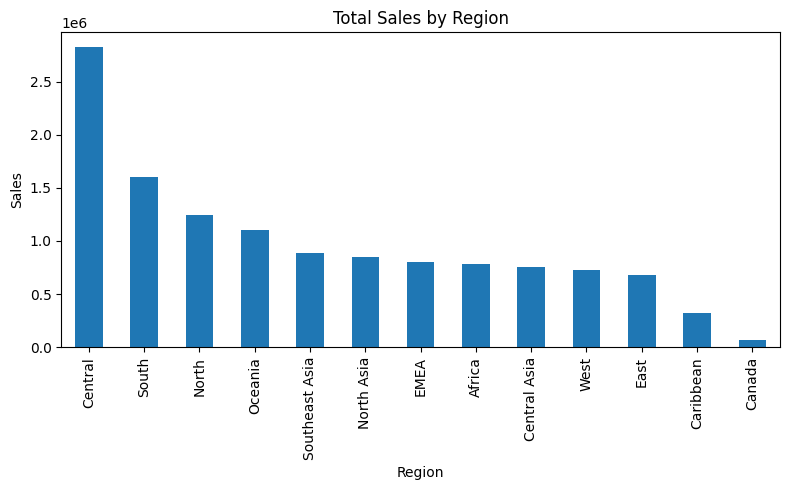

In [32]:
plt.figure(figsize=(8,5))
sales_by_region.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

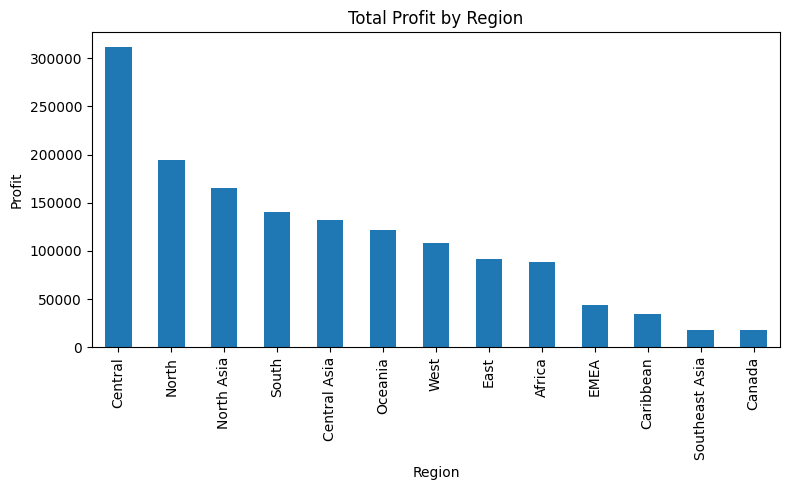

In [34]:
profit_by_region = df.groupby("region")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
profit_by_region.plot(kind="bar")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### Interpretation

The Central region generates the highest total sales, followed by the East region.

### Business Insight

This suggests that the central region is a key revenue driver and may benefit from additional investment or expansion strategies.

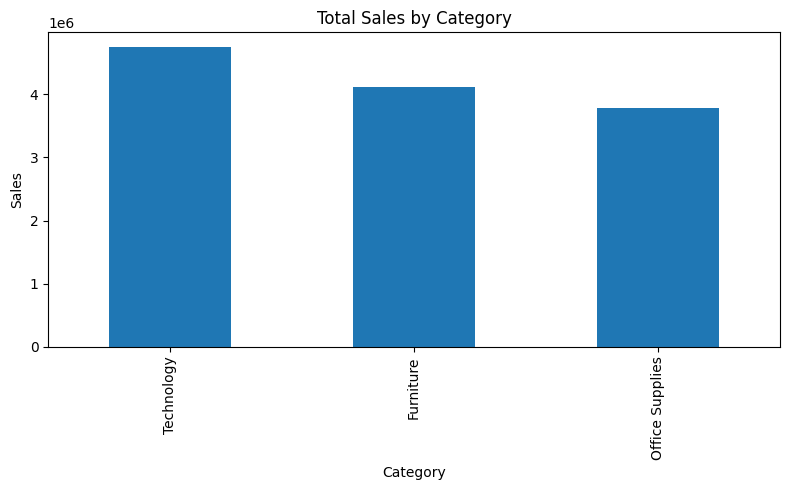

In [40]:
sales_by_category = df.groupby("category")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_by_category.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

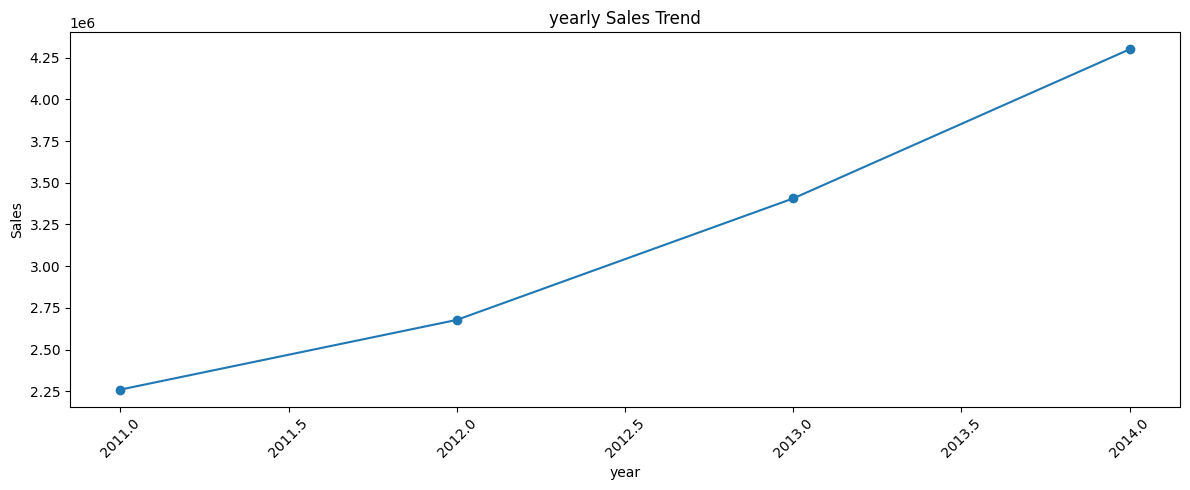

In [56]:
monthly_sales = df.groupby("year")["sales"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("yearly Sales Trend")
plt.xlabel("year")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

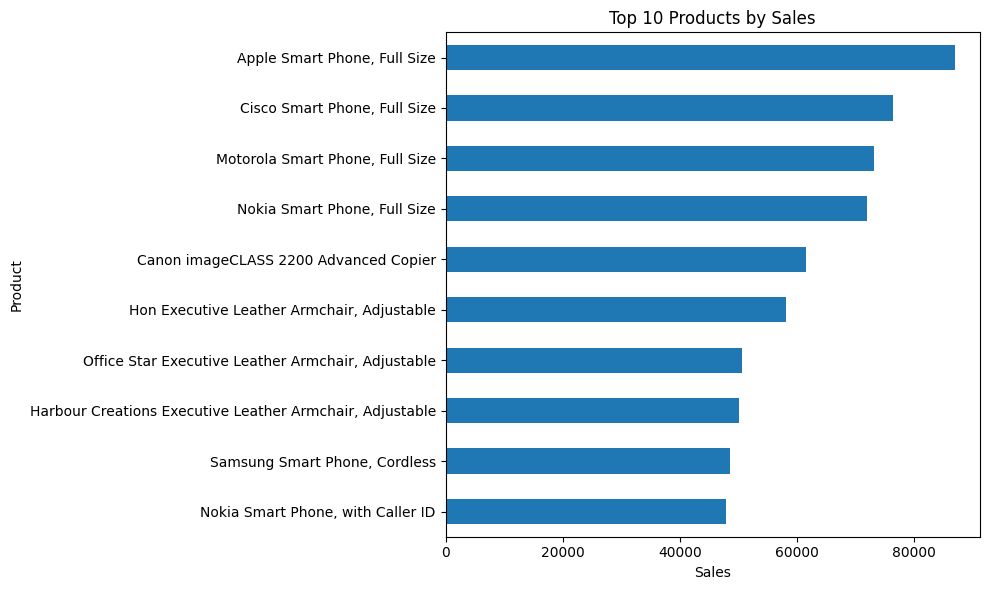

In [49]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

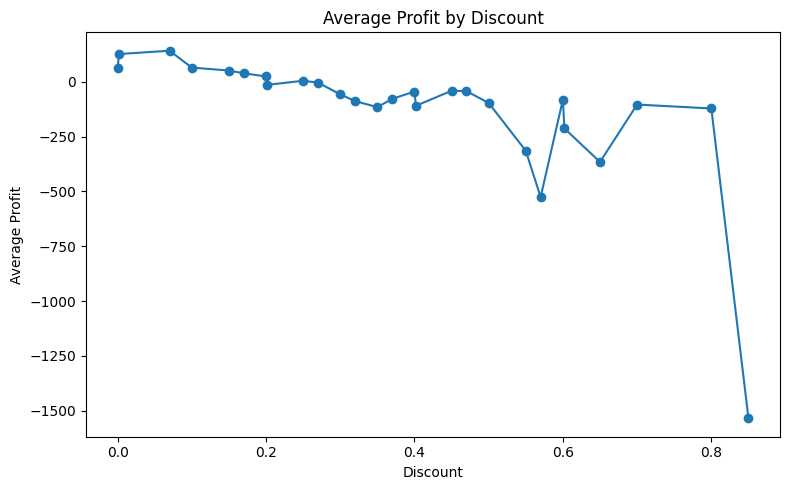

In [51]:
discount_profit = df.groupby("discount")["profit"].mean()

plt.figure(figsize=(8,5))
discount_profit.plot(kind="line", marker="o")
plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.show()

Higher discounts do not always lead to higher profit. In some cases, profit decreases as discount increases. This suggests the business should review its discount strategy.

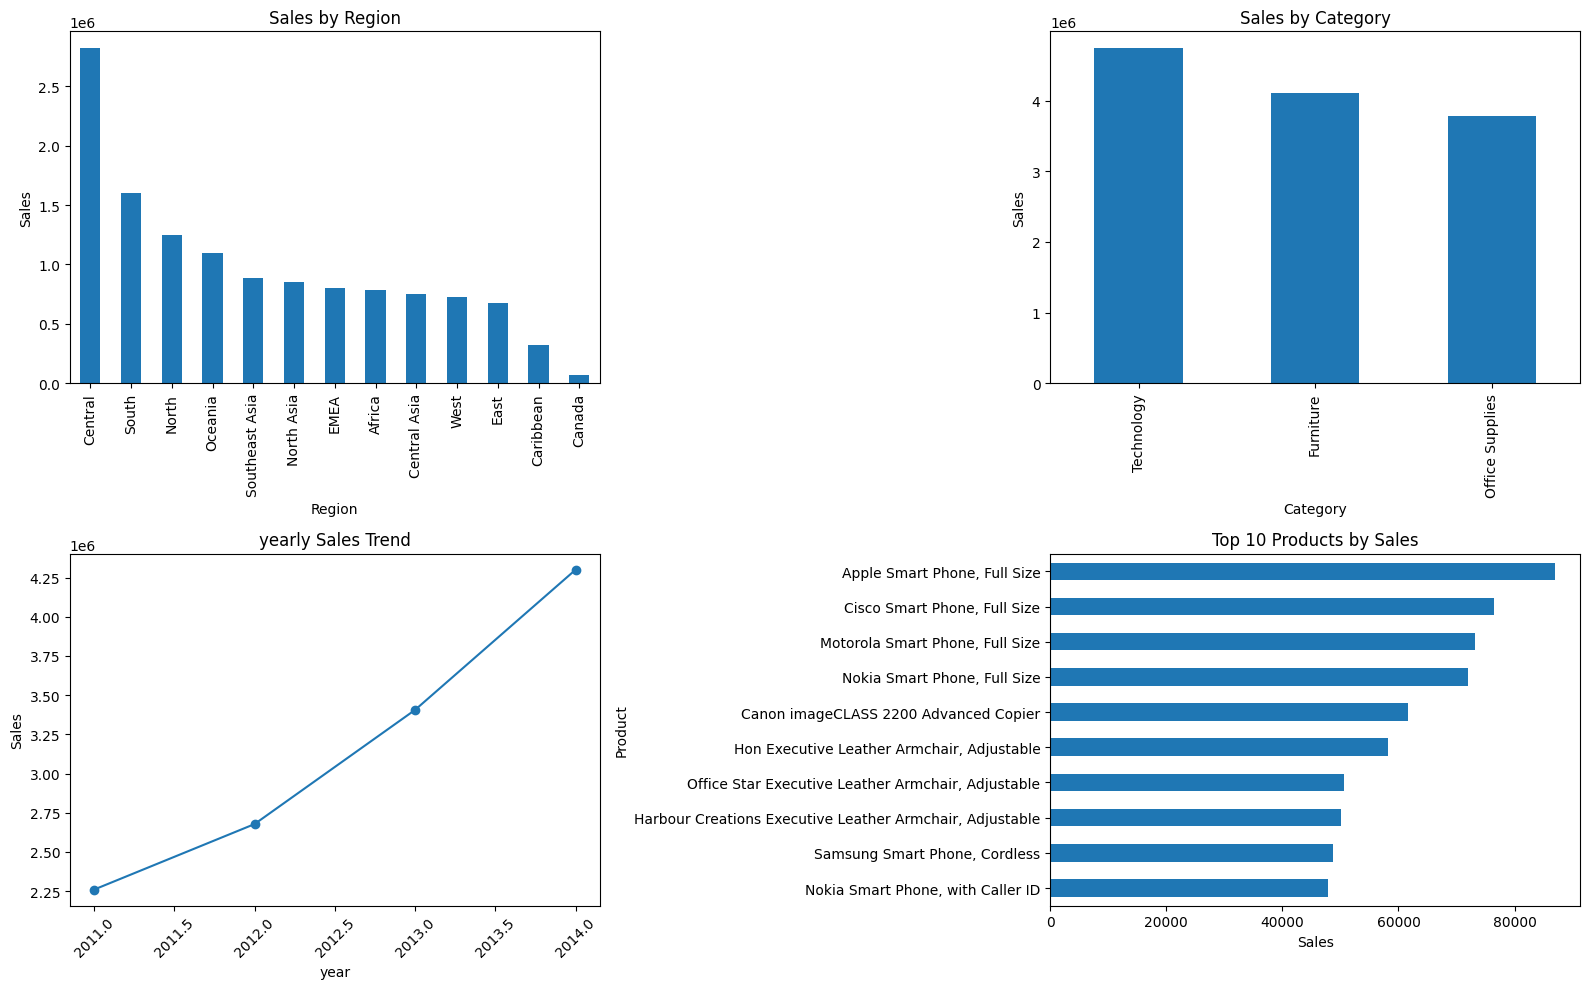

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

sales_by_region.plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Sales by Region")
axes[0,0].set_xlabel("Region")
axes[0,0].set_ylabel("Sales")

sales_by_category.plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Sales by Category")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Sales")

monthly_sales.plot(kind="line", marker="o", ax=axes[1,0])
axes[1,0].set_title("yearly Sales Trend")
axes[1,0].set_xlabel("year")
axes[1,0].set_ylabel("Sales")
axes[1,0].tick_params(axis="x", rotation=45)

top_products.plot(kind="barh", ax=axes[1,1])
axes[1,1].set_title("Top 10 Products by Sales")
axes[1,1].set_xlabel("Sales")
axes[1,1].set_ylabel("Product")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig("C:/Users/HP/Desktop/sales-dashboard-project/Images/sales_dashboard.png", dpi=300)
plt.show()

## Key Insights

1. The Central region generated the highest sales, followed by South and North, while Canada and the Caribbean contributed the least.
2. Technology is the top-performing category, with higher sales than Furniture and Office Supplies.
3. Sales show a consistent upward trend from 2011 to 2014, indicating strong business growth over time.
4. A small number of products (mainly smartphones) contribute significantly to total sales, showing a high concentration of revenue among top products.
5. Lower-performing regions and products represent potential opportunities for growth if properly targeted.

## Business Recommendations

- Increase focus on the Central region through targeted marketing and inventory expansion.
- Review discount strategies to prevent profit loss.
- Promote high-performing products to maximize revenue.
- Investigate seasonal trends to optimize inventory planning.

## What I Learned

This project helped me understand the importance of:

- Cleaning data before analysis
- Using aggregation techniques to uncover trends
- Translating data into business insights rather than just visualizations

It also highlighted how small data issues can significantly impact results.